In [1]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.layers import Dense, Conv2D, MaxPool2D , Flatten,Dropout
import seaborn as sns


In [2]:

# Load the data
train = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
test = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")
train.head(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
y = train.label
X = train.loc[:,'pixel0':]
X.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Check the data
X.isnull().any().describe()

count       784
unique        1
top       False
freq        784
dtype: object

In [5]:
test.isnull().any().describe()

count       784
unique        1
top       False
freq        784
dtype: object

In [6]:
print(f'Number of rows: {train.shape[0]};  Number of columns: {train.shape[1]}; No of missing values: {sum(train.isna().sum())}')

Number of rows: 42000;  Number of columns: 785; No of missing values: 0


# Normalize the data

In [7]:

X= X / 255.0
test = test / 255.0

 # Split training 

In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.33, random_state=42, stratify = y)

### It will zero variance features
from sklearn.feature_selection import VarianceThreshold
var_thres=VarianceThreshold(threshold=0)
var_thres.fit(X)

In [9]:
### It will zero variance features
from sklearn.feature_selection import VarianceThreshold
var_thres=VarianceThreshold(threshold=0)
var_thres.fit(X_train)

VarianceThreshold(threshold=0)

In [10]:
var_thres.get_support()

array([False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False, False, False, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [11]:
### Finding non constant features
sum(var_thres.get_support())

705

In [12]:
# Lets Find non-constant features 
len(X.columns[var_thres.get_support()])

705

In [13]:
constant_columns = [column for column in X_train.columns
                    if column not in X_train.columns[var_thres.get_support()]]

print(len(constant_columns))

79


In [14]:
for column in constant_columns:
    print(column)

pixel0
pixel1
pixel2
pixel3
pixel4
pixel5
pixel6
pixel7
pixel8
pixel9
pixel10
pixel11
pixel16
pixel17
pixel18
pixel19
pixel20
pixel21
pixel22
pixel23
pixel24
pixel25
pixel26
pixel27
pixel28
pixel29
pixel30
pixel31
pixel52
pixel53
pixel54
pixel55
pixel56
pixel57
pixel58
pixel82
pixel83
pixel84
pixel85
pixel86
pixel111
pixel112
pixel139
pixel140
pixel141
pixel168
pixel196
pixel392
pixel420
pixel421
pixel448
pixel449
pixel476
pixel532
pixel560
pixel644
pixel645
pixel671
pixel672
pixel673
pixel699
pixel700
pixel701
pixel727
pixel728
pixel729
pixel730
pixel731
pixel754
pixel755
pixel756
pixel757
pixel758
pixel759
pixel760
pixel780
pixel781
pixel782
pixel783


train.drop(corr_features,axis=1)


### 2. Feature Selection- With Correlation
In this step we will be removing the features which are highly correlated 

In [15]:
from sklearn.datasets import load_boston

In [16]:
X_train.corr()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
pixel0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pixel1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pixel2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pixel3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pixel4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pixel779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.000289,-0.000217,-0.00015,0.257784,0.905833,1.0,NaN,NaN,NaN,NaN
pixel780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pixel781,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pixel782,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [18]:
corr_features = correlation(X_train, 0.7)
len(set(corr_features))

495

In [19]:
corr_features

{'pixel100',
 'pixel101',
 'pixel102',
 'pixel103',
 'pixel104',
 'pixel105',
 'pixel106',
 'pixel119',
 'pixel120',
 'pixel121',
 'pixel122',
 'pixel123',
 'pixel124',
 'pixel125',
 'pixel126',
 'pixel127',
 'pixel128',
 'pixel129',
 'pixel13',
 'pixel130',
 'pixel131',
 'pixel132',
 'pixel133',
 'pixel134',
 'pixel136',
 'pixel14',
 'pixel146',
 'pixel147',
 'pixel148',
 'pixel149',
 'pixel15',
 'pixel150',
 'pixel151',
 'pixel152',
 'pixel153',
 'pixel154',
 'pixel155',
 'pixel156',
 'pixel157',
 'pixel158',
 'pixel159',
 'pixel160',
 'pixel161',
 'pixel162',
 'pixel163',
 'pixel164',
 'pixel174',
 'pixel175',
 'pixel176',
 'pixel177',
 'pixel178',
 'pixel179',
 'pixel180',
 'pixel181',
 'pixel182',
 'pixel183',
 'pixel184',
 'pixel185',
 'pixel186',
 'pixel187',
 'pixel188',
 'pixel189',
 'pixel190',
 'pixel191',
 'pixel192',
 'pixel201',
 'pixel202',
 'pixel203',
 'pixel204',
 'pixel205',
 'pixel206',
 'pixel207',
 'pixel208',
 'pixel209',
 'pixel210',
 'pixel211',
 'pixel212',
 '

train.drop(corr_features,axis=1)

## 3.Feature Selection-Information gain - mutual information In Classification Problem Statements

Mutual Information
MI Estimate mutual information for a discrete target variable.

Mutual information (MI) between two random variables is a non-negative value, which measures the dependency between the variables. It is equal to zero if and only if two random variables are independent, and higher values mean higher dependency.

The function relies on nonparametric methods based on entropy estimation from k-nearest neighbors distances.

Inshort

A quantity called mutual information measures the amount of information one can obtain from one random variable given another.

The mutual information between two random variables X and Y can be stated formally as follows:

I(X ; Y) = H(X) – H(X | Y) Where I(X ; Y) is the mutual information for X and Y, H(X) is the entropy for X and H(X | Y) is the conditional entropy for X given Y. The result has the units of bits.

In [20]:
from sklearn.feature_selection import mutual_info_classif
# determine the mutual information
mutual_info = mutual_info_classif(X_train, y_train)
mutual_info

array([3.37515321e-03, 8.01090422e-03, 1.96136088e-03, 0.00000000e+00,
       2.95922601e-04, 3.17783906e-03, 0.00000000e+00, 6.15995054e-05,
       6.57577033e-03, 3.92332265e-03, 0.00000000e+00, 4.76608283e-04,
       9.17368141e-03, 1.60597294e-03, 0.00000000e+00, 3.23850141e-03,
       0.00000000e+00, 5.79017961e-03, 0.00000000e+00, 5.12732062e-03,
       0.00000000e+00, 3.82980419e-03, 0.00000000e+00, 9.69168547e-04,
       0.00000000e+00, 3.19552637e-03, 2.92551204e-03, 0.00000000e+00,
       5.10850866e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.28845209e-03, 7.80727622e-03, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 7.28420642e-03, 6.18384177e-03,
       5.78275041e-03, 4.06370964e-03, 0.00000000e+00, 6.88886294e-03,
       4.98950022e-03, 6.71745229e-03, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 7.27558110e-03, 1.14857936e-03, 4.67356099e-03,
       0.00000000e+00, 7.39978420e-04, 4.89108883e-03, 1.80007292e-03,
      

In [21]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

pixel378    0.288229
pixel406    0.286506
pixel434    0.283609
pixel461    0.268313
pixel350    0.261771
              ...   
pixel79     0.000000
pixel703    0.000000
pixel702    0.000000
pixel701    0.000000
pixel84     0.000000
Length: 784, dtype: float64

<AxesSubplot:>

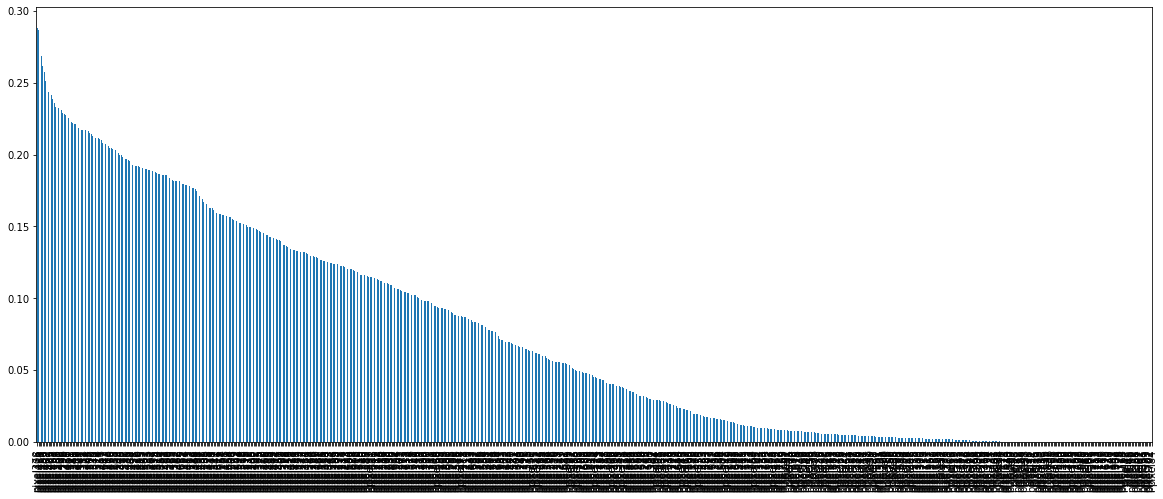

In [22]:
#let's plot the ordered mutual_info values per feature
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 8))

In [23]:
from sklearn.feature_selection import SelectKBest

In [24]:
#No we Will select the  top 5 important features
sel_ten_cols = SelectKBest(mutual_info_classif, k=10)
sel_ten_cols.fit(X_train, y_train)
X_train.columns[sel_ten_cols.get_support()]

Index(['pixel350', 'pixel377', 'pixel378', 'pixel405', 'pixel406', 'pixel409',
       'pixel433', 'pixel434', 'pixel461', 'pixel462'],
      dtype='object')

train.drop(sel_ten_cols,axis=1)

### 4.Fisher Score- Chisquare  Test For Feature Selection

Compute chi-squared stats between each non-negative feature and class.

This score should be used to evaluate categorical variables in a classification task.
This score can be used to select the n_features features with the highest values for the test chi-squared statistic from X, which must contain only non-negative features such as booleans or frequencies (e.g., term counts in document classification), relative to the classes.

Recall that the chi-square test measures dependence between stochastic variables, so using this function “weeds out” the features that are the most likely to be independent of class and therefore irrelevant for classification. The Chi Square statistic is commonly used for testing relationships between categorical variables.

It compares the observed distribution of the different classes of target Y among the different categories of the feature, against the expected distribution of the target classes, regardless of the feature categories.

In [25]:
## Perform chi2 test
### chi2 returns 2 values
### Fscore and the pvalue
from sklearn.feature_selection import chi2
f_p_values=chi2(X_train,y_train)

In [26]:
f_p_values

(array([           nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
        3.55042767e-01, 7.66892378e+00, 7.66892378e+00, 3.19538491e-01,
                   nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
        5.74212715e-01, 1.97385621e+00, 1.34222222e+01, 2.53825364e+01,
        3.08040251e+01, 4.19240343e+01, 9.82087156e+01, 1.56534462e+02,
        1.80880922e+02, 1.66396110e+02, 1.20009434e+02, 1.24202214e+02,
        1.20363383e+02, 7.44327148e+01, 6.85756225e+01, 6.70752228e+01,
        3.47398693e+01, 1.48577540e+01, 1.58626263e+01, 7.60831848e+00,
                   nan,            nan,            nan,         

In [27]:
import pandas as pd
p_values=pd.Series(f_p_values[1])
p_values.index=X_train.columns
p_values

pixel0         NaN
pixel1         NaN
pixel2         NaN
pixel3         NaN
pixel4         NaN
             ...  
pixel779    0.9101
pixel780       NaN
pixel781       NaN
pixel782       NaN
pixel783       NaN
Length: 784, dtype: float64

In [28]:
p_values.sort_index(ascending=False)

pixel99     0.0
pixel98     0.0
pixel97     0.0
pixel96     0.0
pixel95     0.0
           ... 
pixel101    0.0
pixel100    0.0
pixel10     NaN
pixel1      NaN
pixel0      NaN
Length: 784, dtype: float64